# Exploring Library Metadata: From Catalog Records to Data Analysis

**Digital Humanities Conference Demo**

This notebook walks through how library catalog records — the metadata that libraries use to describe books — can be turned into structured data and analysed computationally.

We will use a sample of **Latin-language books published in the 17th century (1600–1699)** drawn from the Library of Congress catalog.

---
### What is a MARC record?

A **MARC record** (MAchine-Readable Cataloging) is the standard format libraries use to describe a book or other item. Think of it as a very structured spreadsheet row, where each piece of information (title, author, subject, language…) sits in a numbered **field**, and each field can have labeled **subfields**.

```
Field 245  →  Title
Field 008  →  A 40-character fixed string encoding language, date, country, etc.
Field 650  →  Subject heading (what the book is about)
```

Our data is stored in **MARC XML** — the same information encoded as XML so it can be parsed by standard tools.

## 0. Setup

In [1]:
import os
from lxml import etree
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

MARC_NS = "http://www.loc.gov/MARC21/slim"
MARC    = f"{{{MARC_NS}}}"

# Path to the XML file produced by the sampler notebook
INPUT_FILE = "latin_books_1600s.xml"
print(f"Input file: {INPUT_FILE}")
print(f"File size : {os.path.getsize(INPUT_FILE) / 1e6:.1f} MB")

Input file: latin_books_1600s.xml
File size : 9.5 MB


---
## 1. Extracting Data from XML Bibliographic Records

We parse the XML file one record at a time. For each record we pull out:

| What | MARC field | Notes |
|---|---|---|
| Title | **245** `$a` / `$b` | Main title + subtitle |
| Language | **008** positions 35–37 | 3-letter ISO code, e.g. `lat` = Latin |
| Publication year | **008** positions 7–10 | Year of first publication |
| Subject headings | **650** `$a` | Topical terms (what the book is about) |
| Geographic subjects | **651** `$a` | Places the book is about |
| Record type | **Leader** position 6 | `a` = text, `e` = map, `c` = music score … |
| Content nature | **008** positions 24–27 | `b` = bibliography, `i` = index … |
| Physical extent | **300** `$a` | Page count string |

### 1.1 Helper functions

In [2]:
def safe_char(s, i, default=""):
    try: return s[i]
    except (IndexError, TypeError): return default

def safe_slice(s, a, b, default=""):
    try:
        r = s[a:b]
        return r if r.strip() else default
    except TypeError:
        return default

# Human-readable labels for Leader/06 record types
RECORD_TYPE_LABELS = {
    "a": "Text (language material)",
    "c": "Music score",
    "d": "Music score (manuscript)",
    "e": "Cartographic",
    "f": "Cartographic (manuscript)",
    "g": "Projected medium",
    "i": "Nonmusical sound recording",
    "j": "Musical sound recording",
    "k": "Still image",
    "m": "Computer file",
    "o": "Kit",
    "p": "Mixed material",
    "r": "3-D object",
    "t": "Text (manuscript)",
}

# Human-readable labels for 008/24-27 content-nature codes
CONTENT_NATURE_LABELS = {
    "a": "Abstracts/summaries",
    "b": "Bibliographies",
    "c": "Catalogs",
    "d": "Dictionaries",
    "e": "Encyclopedias",
    "f": "Handbooks/manuals",
    "g": "Legal articles",
    "i": "Indexes",
    "j": "Patent documents",
    "k": "Discographies",
    "l": "Legislation",
    "m": "Theses/dissertations",
    "n": "Surveys",
    "o": "Reviews",
    "p": "Programmed texts",
    "q": "Filmographies",
    "r": "Directories",
    "s": "Statistics",
    "t": "Technical reports",
    "u": "Standards/specifications",
    "v": "Legal cases",
    "w": "Law reports/digests",
    "z": "Treaties",
    "5": "Calendars",
    "6": "Comics/graphic novels",
}

### 1.2 Parse the records

In [3]:
records_main     = []   # one row per record
records_subjects = []   # one row per subject heading (many per record)

context = etree.iterparse(
    INPUT_FILE, events=("end",), tag=f"{MARC}record", recover=True
)

for _, record in context:

    # ── Identifier ──────────────────────────────────────────────────────────
    lc_id = ""
    for sf in record.findall(f'{MARC}datafield[@tag="010"]/{MARC}subfield[@code="a"]'):
        if sf.text:
            lc_id = sf.text.strip()

    # ── 008 fixed-length field ──────────────────────────────────────────────
    f008 = ""
    cf = record.find(f'{MARC}controlfield[@tag="008"]')
    if cf is not None and cf.text:
        f008 = cf.text

    pub_year   = safe_slice(f008,  7, 11)
    language   = safe_slice(f008, 35, 38)
    cont_codes = safe_slice(f008, 24, 28)

    # Publication year as integer (skip malformed values)
    try:
        pub_year_int = int(pub_year)
    except ValueError:
        pub_year_int = None

    # ── Leader ──────────────────────────────────────────────────────────────
    leader = record.find(f"{MARC}leader")
    leader_text  = leader.text if (leader is not None and leader.text) else ""
    record_type_code  = safe_char(leader_text, 6)
    record_type_label = RECORD_TYPE_LABELS.get(record_type_code, f"Other ({record_type_code})")

    # ── Content-nature codes from 008/24-27 ─────────────────────────────────
    content_natures = [
        CONTENT_NATURE_LABELS.get(ch, f"Other ({ch})")
        for ch in cont_codes if ch not in (" ", "")
    ]

    # ── Title (245 $a + $b) ─────────────────────────────────────────────────
    title = ""
    for tf in record.findall(f'{MARC}datafield[@tag="245"]'):
        parts = []
        for sf in tf.findall(f"{MARC}subfield"):
            if sf.get("code") in ("a", "b") and sf.text:
                parts.append(sf.text.strip().rstrip("/,:;").strip())
        title = " ".join(parts)
        break   # only one 245 per record

    # ── Physical extent (300 $a) ────────────────────────────────────────────
    pages = ""
    for pf in record.findall(f'{MARC}datafield[@tag="300"]'):
        sf = pf.find(f'{MARC}subfield[@code="a"]')
        if sf is not None and sf.text:
            pages = sf.text.strip()
        break

    # ── Subject headings (650 topical, 651 geographic) ──────────────────────
    for tag, stype in (("650", "Topical"), ("651", "Geographic")):
        for sf_field in record.findall(f'{MARC}datafield[@tag="{tag}"]'):
            if sf_field.get("ind2") != "0":   # LCSH only
                continue
            sf_a = sf_field.find(f'{MARC}subfield[@code="a"]')
            if sf_a is not None and sf_a.text:
                records_subjects.append({
                    "id":      lc_id,
                    "type":    stype,
                    "heading": sf_a.text.strip().rstrip("."),
                })

    # ── Assemble main row ───────────────────────────────────────────────────
    records_main.append({
        "id":               lc_id,
        "title":            title,
        "language":         language,
        "pub_year":         pub_year_int,
        "record_type_code": record_type_code,
        "record_type":      record_type_label,
        "content_natures":  content_natures,   # list; exploded later
        "pages":            pages,
    })

    # Free element from memory
    record.clear()
    parent = record.getparent()
    if parent is not None:
        while len(parent) and parent[0] is not record:
            del parent[0]

del context

df_main     = pd.DataFrame(records_main)
df_subjects = pd.DataFrame(records_subjects)

print(f"Records parsed : {len(df_main):,}")
print(f"Subject entries: {len(df_subjects):,}")
df_main.head()

Records parsed : 2,745
Subject entries: 4,828


,id,title,language,pub_year,record_type_code,record_type,content_natures,pages
0,00510995,Lucii Annaei Senecae Tragoediae ad doctorum vi...,lat,1607,a,Text (language material),[],"317, [3] p. (final leaf blank) ;"
1,00515569,Deo auctore disceptationes hasce ex IV libris ...,lat,1602,a,Text (language material),[],"[8], [409, i.e. 408], [12] p. ;"
2,00515571,Andreae Knichen JC. velitatio apologetica in q...,lat,1604,a,Text (language material),[],[60] p. ;
3,00515676,"Manuductio ad logicam, siue, Dialectica studio...",lat,1620,a,Text (language material),[],"[12], 204 p. ;"
4,00515694,Dn. Philippus Decius Mediolanensis I.C. celebe...,lat,1619,a,Text (language material),[],"[56] ([55/56] blank), 559, [1] p. ;"


### 1.3 A quick look at the raw XML

Before going further, let's peek at one record so we can see what the raw data looks like — and appreciate how much work the parser is doing.

In [4]:
# Parse again just to show one raw record
context = etree.iterparse(
    INPUT_FILE, events=("end",), tag=f"{MARC}record", recover=True
)
_, sample_record = next(iter(context))
del context

raw_xml = etree.tostring(sample_record, pretty_print=True, encoding="unicode")
print(raw_xml[:3000], "..." if len(raw_xml) > 3000 else "")

<record xmlns="http://www.loc.gov/MARC21/slim">
  <leader>01104cam a2200265 a 4500</leader>
  <controlfield tag="001">   00510995 </controlfield>
  <controlfield tag="003">DLC</controlfield>
  <controlfield tag="005">20170729094328.0</controlfield>
  <controlfield tag="008">991213s1607    fr            000 0 lat  </controlfield>
  <datafield tag="010" ind1=" " ind2=" ">
    <subfield code="a">   00510995 </subfield>
  </datafield>
  <datafield tag="040" ind1=" " ind2=" ">
    <subfield code="a">DLC</subfield>
    <subfield code="e">dcrb</subfield>
    <subfield code="c">DLC</subfield>
    <subfield code="d">DLC</subfield>
  </datafield>
  <datafield tag="050" ind1="0" ind2="0">
    <subfield code="a">PA6664</subfield>
    <subfield code="b">.A2 1607</subfield>
  </datafield>
  <datafield tag="100" ind1="1" ind2=" ">
    <subfield code="a">Seneca, Lucius Annaeus,</subfield>
    <subfield code="d">approximately 4 B.C.-65 A.D.</subfield>
  </datafield>
  <datafield tag="240" ind1="1" ind2

### 1.4 Descriptive metadata at a glance

In [5]:
print("=== Dataset overview ===")
print(f"Total records     : {len(df_main):,}")
print(f"Records with title: {df_main['title'].str.len().gt(0).sum():,}")
print(f"Unique languages  : {df_main['language'].nunique()}")
print(f"Year range        : {df_main['pub_year'].min()} – {df_main['pub_year'].max()}")
print()
print("=== Record types ===")
print(df_main["record_type"].value_counts().to_string())
print()
print("=== Language distribution (top 10) ===")
print(df_main["language"].value_counts().head(10).to_string())

=== Dataset overview ===
Total records     : 2,745
Records with title: 2,745
Unique languages  : 1
Year range        : 1600 – 1699

=== Record types ===
record_type
Text (language material)    2741
Text (manuscript)              4

=== Language distribution (top 10) ===
language
lat    2745


---
## 2. Data Analysis and Visualization

Now that the data is in tidy DataFrames we can start asking questions.

### 2.1 When were these books published?

The 17th century is our target window (1600–1699). How are publications distributed across the decades?

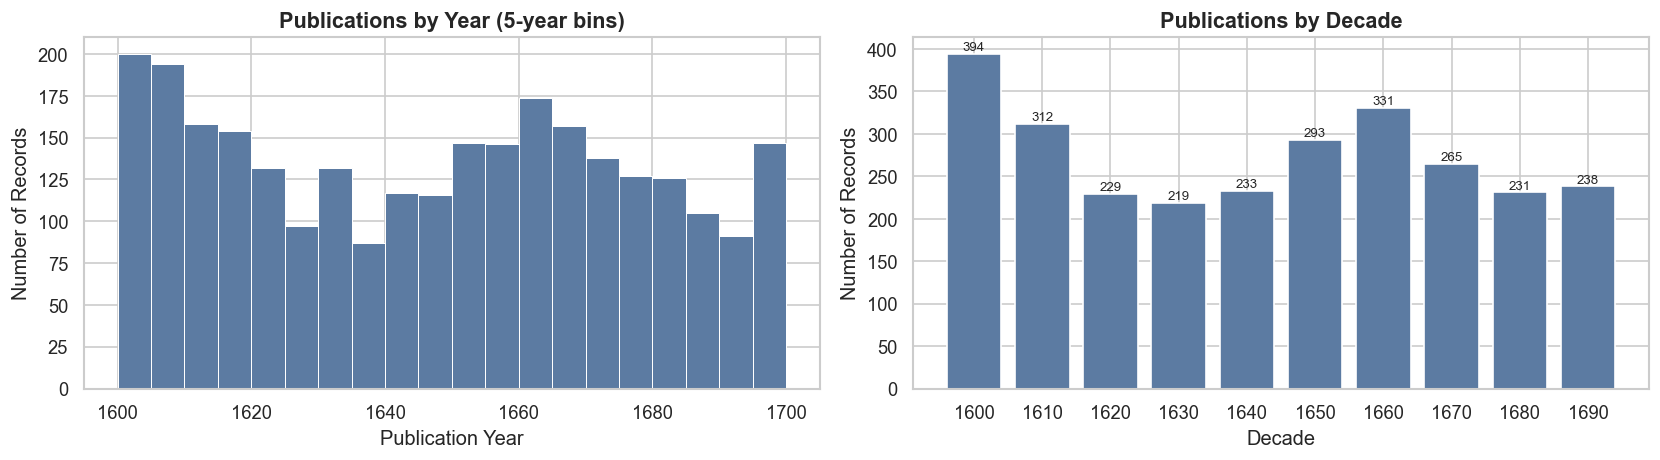

Decade breakdown:
decade
1600    394
1610    312
1620    229
1630    219
1640    233
1650    293
1660    331
1670    265
1680    231
1690    238


In [6]:
df_years = df_main.dropna(subset=["pub_year"]).copy()
df_years["decade"] = (df_years["pub_year"] // 10 * 10).astype(int)
decade_counts = df_years["decade"].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: year-by-year histogram
axes[0].hist(df_years["pub_year"], bins=range(1600, 1701, 5),
             color="#5c7ba2", edgecolor="white", linewidth=0.6)
axes[0].set_title("Publications by Year (5-year bins)", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Publication Year")
axes[0].set_ylabel("Number of Records")
axes[0].xaxis.set_major_locator(mticker.MultipleLocator(20))

# Right: by decade
bars = axes[1].bar(decade_counts.index, decade_counts.values,
                   width=8, color="#5c7ba2", edgecolor="white")
axes[1].set_title("Publications by Decade", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Decade")
axes[1].set_ylabel("Number of Records")
axes[1].xaxis.set_major_locator(mticker.MultipleLocator(10))
for bar in bars:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 str(int(bar.get_height())), ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.savefig("fig_pub_years.png", bbox_inches="tight")
plt.show()
print("Decade breakdown:")
print(decade_counts.to_string())

### 2.2 What languages are represented?

Although we filtered for Latin (`lat`), some records contain multi-language codes or may carry a different primary language due to cataloging conventions.

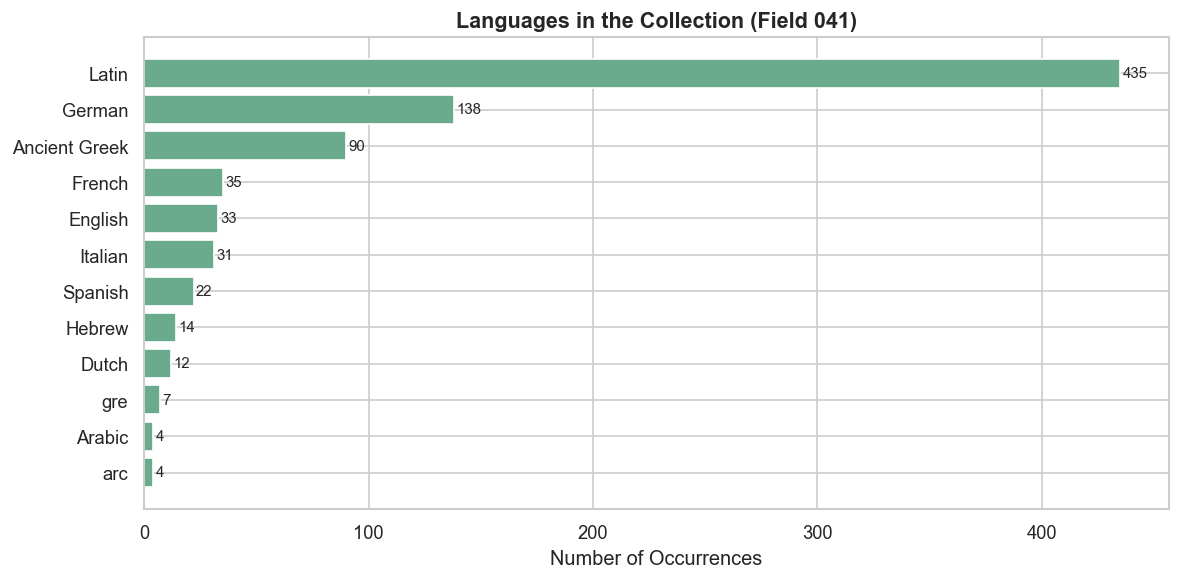

In [7]:
# Also pull 041 $a codes (explicit language field) for richer coverage
lang_041 = []
context = etree.iterparse(
    INPUT_FILE, events=("end",), tag=f"{MARC}record", recover=True
)
for _, record in context:
    cf = record.find(f'{MARC}controlfield[@tag="008"]')
    lc_id = ""
    sf010 = record.find(f'{MARC}datafield[@tag="010"]/{MARC}subfield[@code="a"]')
    if sf010 is not None and sf010.text:
        lc_id = sf010.text.strip()
    for lf in record.findall(f'{MARC}datafield[@tag="041"]'):
        for sf in lf.findall(f"{MARC}subfield"):
            if sf.get("code") == "a" and sf.text:
                for i in range(0, len(sf.text), 3):
                    code = sf.text[i:i+3].strip()
                    if code:
                        lang_041.append({"id": lc_id, "lang_code": code})
    record.clear()
    p = record.getparent()
    if p is not None:
        while len(p) and p[0] is not record: del p[0]
del context

df_lang041 = pd.DataFrame(lang_041)

# ISO 639-2 labels for the most common codes in early-modern Latin scholarship
LANG_LABELS = {
    "lat": "Latin", "ger": "German", "fre": "French", "eng": "English",
    "ita": "Italian", "spa": "Spanish", "grc": "Ancient Greek",
    "heb": "Hebrew", "ara": "Arabic", "dut": "Dutch", "por": "Portuguese",
    "pol": "Polish", "swe": "Swedish", "dan": "Danish", "hun": "Hungarian",
    "cze": "Czech", "rum": "Romanian", "rus": "Russian",
}

lang_counts = df_lang041["lang_code"].value_counts().head(12)
lang_labels = [LANG_LABELS.get(c, c) for c in lang_counts.index]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(lang_labels[::-1], lang_counts.values[::-1], color="#6aab8e", edgecolor="white")
ax.set_title("Languages in the Collection (Field 041)", fontsize=13, fontweight="bold")
ax.set_xlabel("Number of Occurrences")
for bar in bars:
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            str(int(bar.get_width())), va="center", fontsize=9)
plt.tight_layout()
plt.savefig("fig_languages.png", bbox_inches="tight")
plt.show()

### 2.3 What are these books about? — Subject Headings

**Library of Congress Subject Headings (LCSH)** are controlled vocabulary terms catalogers assign to describe a book's content. Each term went through an approval process and comes from a shared thesaurus, making them consistent across millions of records — very different from user-generated tags.

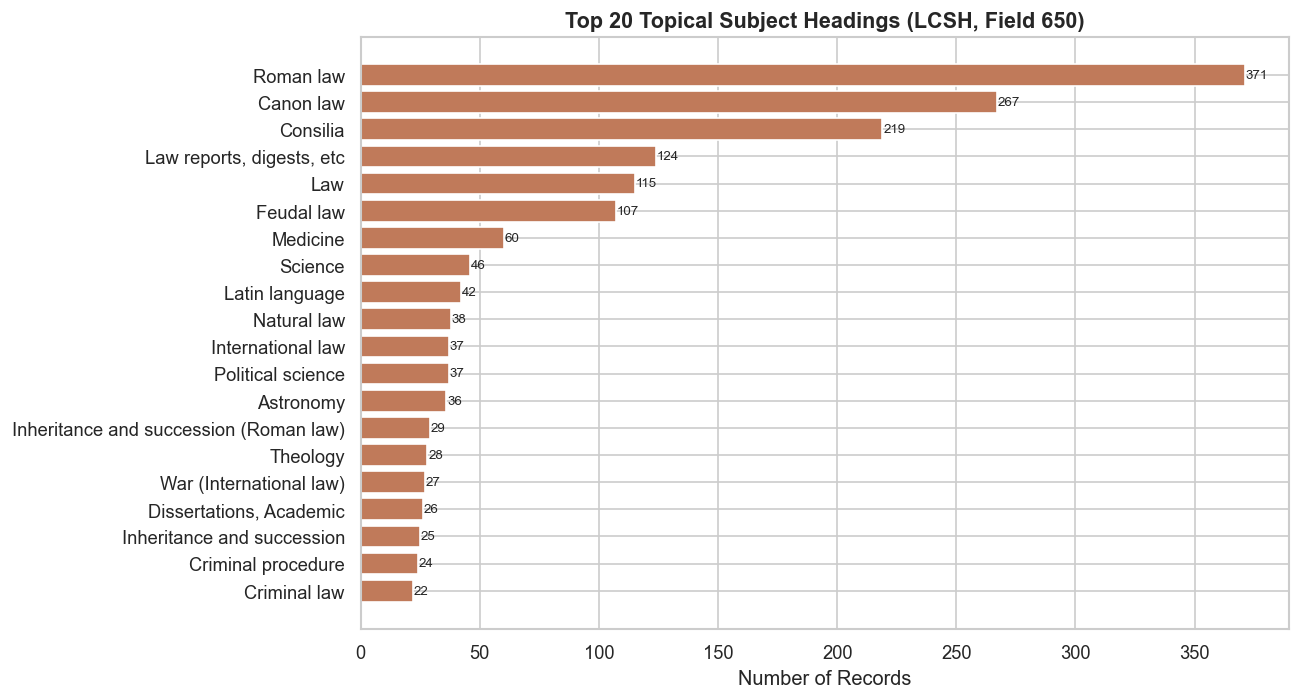

In [8]:
top_topical = (
    df_subjects[df_subjects["type"] == "Topical"]["heading"]
    .value_counts()
    .head(20)
)

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(top_topical.index[::-1], top_topical.values[::-1],
               color="#c07a5a", edgecolor="white")
ax.set_title("Top 20 Topical Subject Headings (LCSH, Field 650)", fontsize=13, fontweight="bold")
ax.set_xlabel("Number of Records")
for bar in bars:
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            str(int(bar.get_width())), va="center", fontsize=8)
plt.tight_layout()
plt.savefig("fig_subjects_topical.png", bbox_inches="tight")
plt.show()

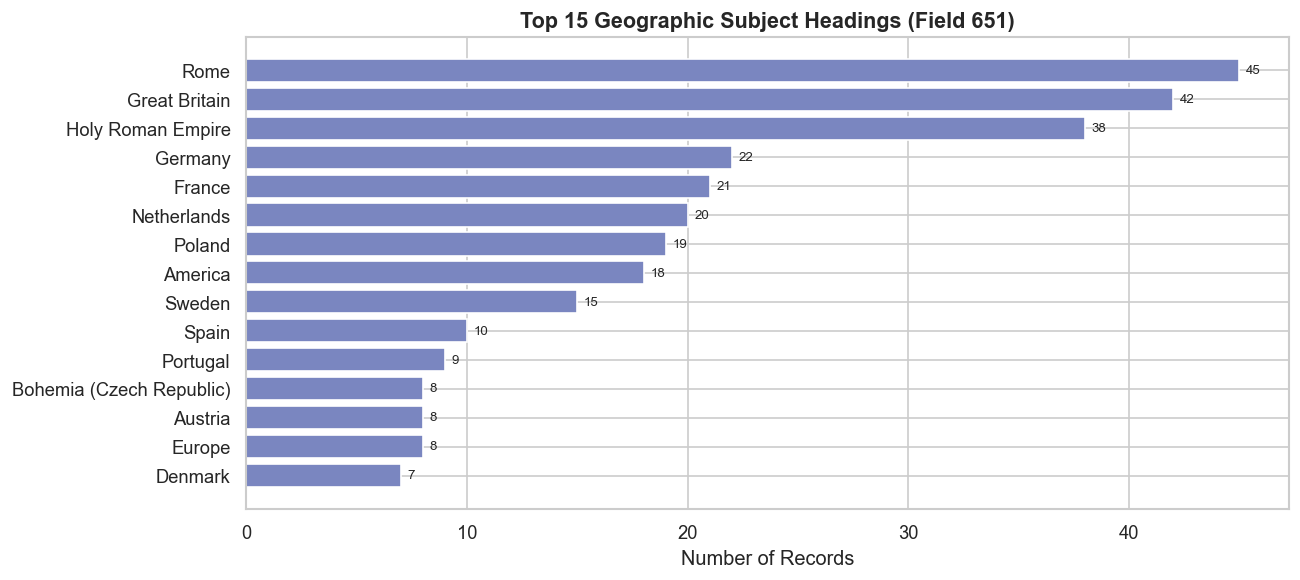

In [9]:
top_geo = (
    df_subjects[df_subjects["type"] == "Geographic"]["heading"]
    .value_counts()
    .head(15)
)

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(top_geo.index[::-1], top_geo.values[::-1],
               color="#7a86c0", edgecolor="white")
ax.set_title("Top 15 Geographic Subject Headings (Field 651)", fontsize=13, fontweight="bold")
ax.set_xlabel("Number of Records")
for bar in bars:
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            str(int(bar.get_width())), va="center", fontsize=8)
plt.tight_layout()
plt.savefig("fig_subjects_geo.png", bbox_inches="tight")
plt.show()

### 2.4 How did subject focus change across the century?

Combining subject headings with publication year lets us see shifts in intellectual focus over the 17th century.

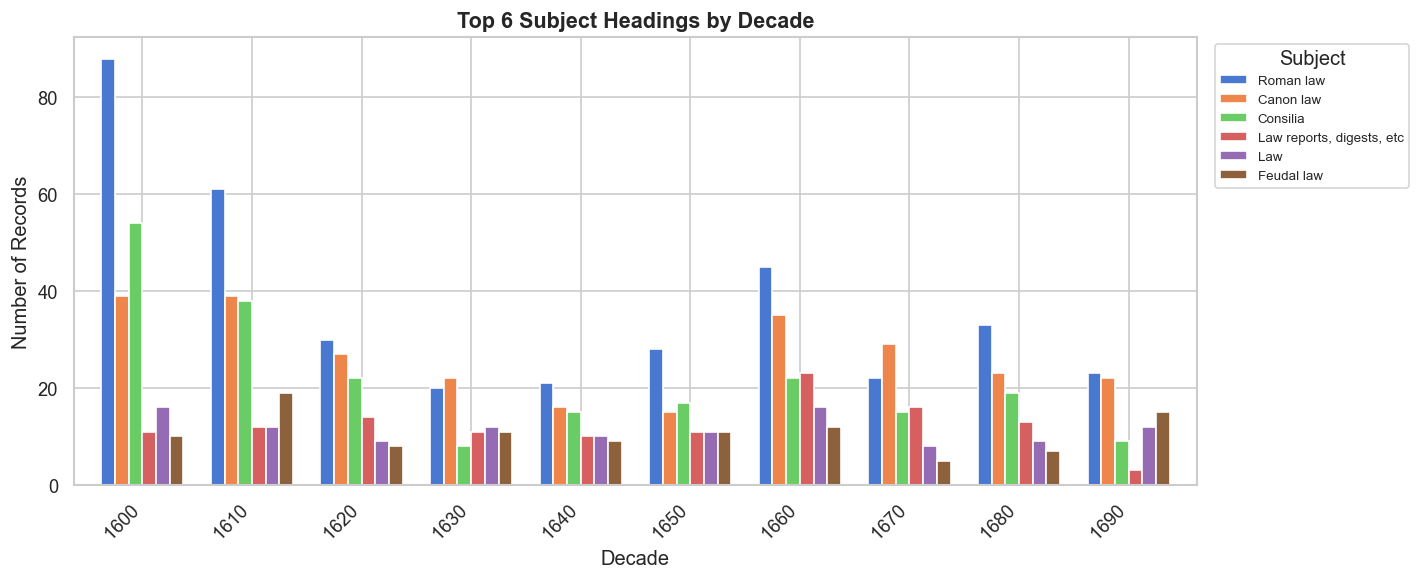

In [10]:
TOP_N = 6
top_subjects = top_topical.head(TOP_N).index.tolist()

df_sub_year = (
    df_subjects[df_subjects["heading"].isin(top_subjects)]
    .merge(df_main[["id", "pub_year"]].dropna(), on="id")
    .assign(decade=lambda d: (d["pub_year"] // 10 * 10).astype(int))
)

pivot = (
    df_sub_year.groupby(["decade", "heading"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=top_subjects)
)

fig, ax = plt.subplots(figsize=(12, 5))
pivot.plot(kind="bar", ax=ax, width=0.75, edgecolor="white")
ax.set_title(f"Top {TOP_N} Subject Headings by Decade", fontsize=13, fontweight="bold")
ax.set_xlabel("Decade")
ax.set_ylabel("Number of Records")
ax.set_xticklabels([str(x) for x in pivot.index], rotation=45, ha="right")
ax.legend(title="Subject", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig("fig_subjects_over_time.png", bbox_inches="tight")
plt.show()

### 2.5 Material Features

MARC records encode several flags about the *nature* of the material beyond just the subject.

**Record type** (Leader/06) tells us the broad format — text, map, music score, etc.

**Content nature** (008/24–27) provides up to four coded characters indicating special characteristics: is this a bibliography? An index? A dissertation? Multiple codes can apply to the same item.

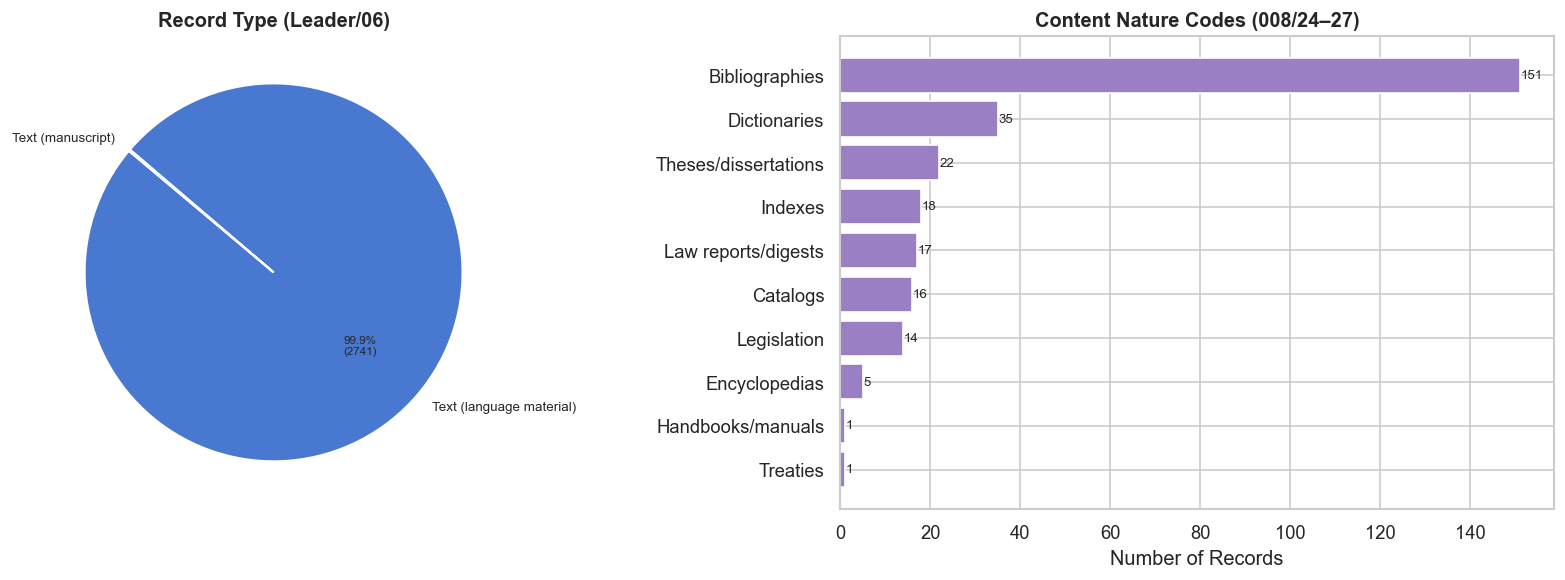

Content nature breakdown:
content_natures
Bibliographies          151
Dictionaries             35
Theses/dissertations     22
Indexes                  18
Law reports/digests      17
Catalogs                 16
Legislation              14
Encyclopedias             5
Handbooks/manuals         1
Treaties                  1


In [12]:
# ── Record type ─────────────────────────────────────────────────────────────
type_counts = df_main["record_type"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: record type
colors_rt = sns.color_palette("muted", len(type_counts))

def autopct_fmt(p):
    count = int(round(p * len(df_main) / 100))
    return f"{p:.1f}%\n({count})" if p > 2 else ""

wedges, texts, autotexts = axes[0].pie(
    type_counts.values, labels=type_counts.index,
    autopct=autopct_fmt,
    colors=colors_rt, startangle=140,
    wedgeprops=dict(edgecolor="white", linewidth=1.2)
)
for t in texts:     t.set_fontsize(8)
for t in autotexts: t.set_fontsize(7)
axes[0].set_title("Record Type (Leader/06)", fontsize=12, fontweight="bold")

# Right: content nature — explode the list column first
df_cn = df_main.explode("content_natures").dropna(subset=["content_natures"])
df_cn = df_cn[df_cn["content_natures"] != ""]
cn_counts = df_cn["content_natures"].value_counts().head(10)

bars = axes[1].barh(cn_counts.index[::-1], cn_counts.values[::-1],
                    color="#9b7fc4", edgecolor="white")
axes[1].set_title("Content Nature Codes (008/24–27)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Number of Records")
for bar in bars:
    axes[1].text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
                 str(int(bar.get_width())), va="center", fontsize=8)

plt.tight_layout()
plt.savefig("fig_material_features.png", bbox_inches="tight")
plt.show()
print("Content nature breakdown:")
print(cn_counts.to_string())

### 2.6 Subject Co-occurrence

Which topics tend to appear together in the same record? A co-occurrence matrix reveals clusters of related subject headings — a simple but powerful form of network analysis.

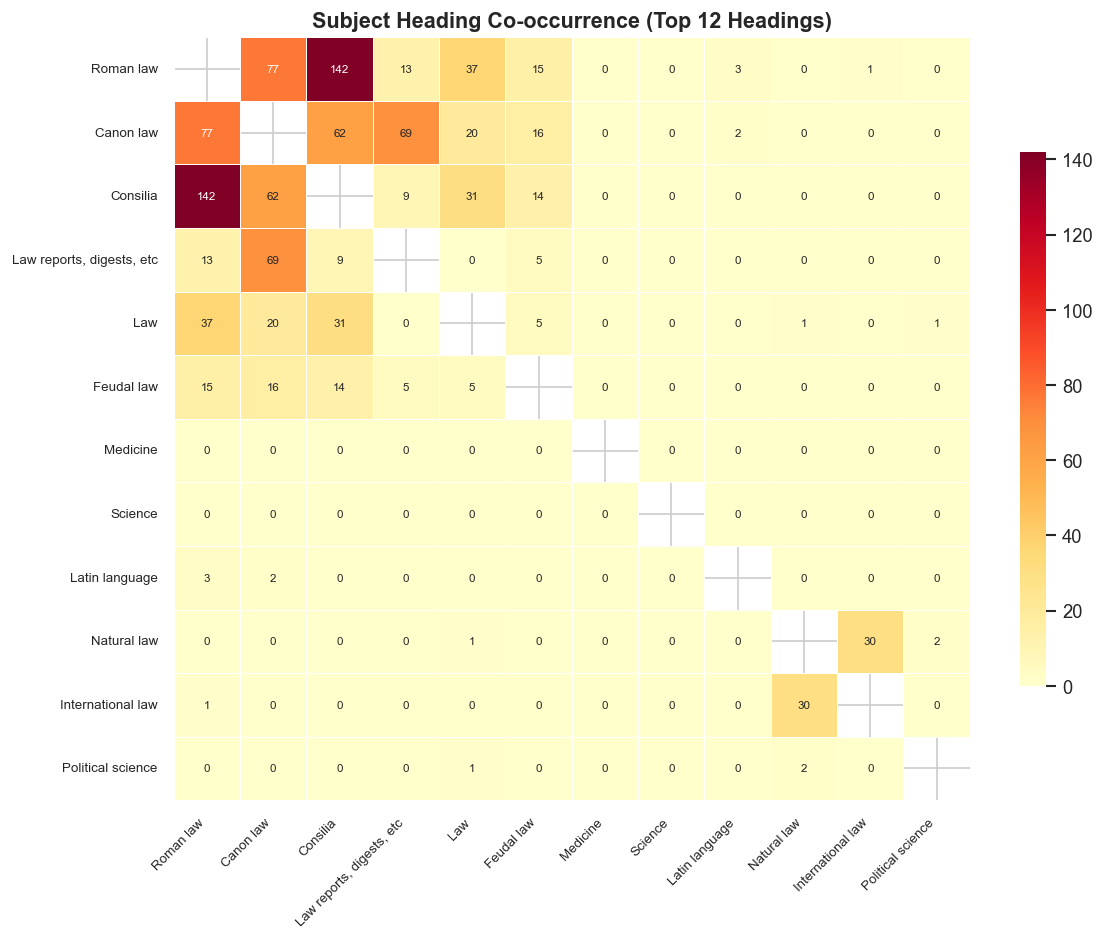

In [13]:
TOP_CO = 12
top_co_subjects = top_topical.head(TOP_CO).index.tolist()

df_co = df_subjects[df_subjects["heading"].isin(top_co_subjects)].copy()

# Build co-occurrence matrix
from itertools import combinations

co_matrix = pd.DataFrame(0, index=top_co_subjects, columns=top_co_subjects)
for rec_id, group in df_co.groupby("id")["heading"]:
    headings = list(set(group.tolist()))
    for a, b in combinations(headings, 2):
        if a in co_matrix.index and b in co_matrix.columns:
            co_matrix.loc[a, b] += 1
            co_matrix.loc[b, a] += 1

# Shorten labels for readability
short_labels = [s[:35] + "…" if len(s) > 35 else s for s in top_co_subjects]
co_matrix.index   = short_labels
co_matrix.columns = short_labels

fig, ax = plt.subplots(figsize=(10, 8))
mask = pd.DataFrame(False, index=co_matrix.index, columns=co_matrix.columns)
for i in range(len(mask)): mask.iloc[i, i] = True  # hide diagonal

sns.heatmap(co_matrix, annot=True, fmt="d", cmap="YlOrRd",
            linewidths=0.5, mask=mask, ax=ax,
            annot_kws={"size": 7}, cbar_kws={"shrink": 0.7})
ax.set_title("Subject Heading Co-occurrence (Top 12 Headings)", fontsize=13, fontweight="bold")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig("fig_cooccurrence.png", bbox_inches="tight")
plt.show()

---
## Summary

In this demo we:

1. **Parsed raw MARC XML** into tidy Python structures without any specialist cataloging software.
2. Extracted **descriptive metadata** (title, language, year) into a record-level DataFrame.
3. Extracted **subject headings** into a separate long-format DataFrame, enabling flexible aggregation.
4. Identified **material features** — record type and content-nature codes — that describe *what kind of document* each record represents.
5. Built several **visualizations** to surface patterns: temporal distribution, language variety, topical focus, and subject co-occurrence.

### What next?

- Merge with full-text corpora (e.g. Early English Books Online, Google Books) using the identifiers in the records.
- Use the geographic headings to map the intellectual geography of 17th-century Latin scholarship.
- Apply topic modeling or word embeddings to the title strings to complement the controlled vocabulary.
- Compare subject coverage across decades or across record types.